In [25]:
# Imports
# Imports for file read/write/saving
from AFMReader.ibw import load_ibw
from pathlib import Path
import numpy as np
import tkinter as tk
from tkinter import filedialog
import os
import pandas as pd

# Imports for fitting etc.

from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [9]:
def line_level_0th_order(image_array):
    # Calculate the median of each row
    # (Median is usually better than mean for AFM so tall features don't skew the result)
    row_medians = np.median(image_array, axis=1, keepdims=True)
    
    # Subtract the row median from each pixel in that row
    leveled_image = image_array - row_medians
    return leveled_image

In [12]:
def line_level_1st_order(image_array):
    leveled_image = np.zeros_like(image_array)
    x_pixels = np.arange(image_array.shape[1])
    
    # Loop through each row
    for i, row in enumerate(image_array):
        # Fit a 1st-degree polynomial (a straight line: y = mx + c)
        slope, intercept = np.polyfit(x_pixels, row, 1)
        
        # Calculate the trend line
        trend_line = slope * x_pixels + intercept
        
        # Subtract the trend from the raw data
        leveled_image[i] = row - trend_line
        
    return leveled_image

In [13]:
def plane_level(image_array):
    # Get the X and Y coordinates for every pixel in the image
    Y_coords, X_coords = np.indices(image_array.shape)
    
    # Flatten the 2D arrays into 1D lists so we can run the math
    X_flat = X_coords.flatten()
    Y_flat = Y_coords.flatten()
    Z_flat = image_array.flatten()
    
    # Create the design matrix for the plane equation
    A = np.c_[X_flat, Y_flat, np.ones_like(X_flat)]
    
    # Solve for the best-fit plane parameters [a, b, c]
    # rcond=None suppresses a numpy warning
    C, _, _, _ = np.linalg.lstsq(A, Z_flat, rcond=None)
    
    # Reconstruct the 2D background plane using the solved parameters
    background_plane = (C[0] * X_coords) + (C[1] * Y_coords) + C[2]
    
    # Subtract the plane from the original image
    leveled_image = image_array - background_plane
    return leveled_image

In [ ]:
def full_leveling(image_data):
    plane_level = plane_leveled (image_data)
    full_level = line_level_0th_order(plane_level)

    return full_level

In [ ]:
def readandsave(filepath, savepath, channel_name=''):     

    image_data, = load_ibw(file_path=filepath, channel=channel_name)

    if channel_name
    if filepath:  # Check if the user selected a file (didn't click Cancel)
            name = Path(filepath).stem
    
    save_name = f"{savepath}{name}.npy"

    np.save(save_name, image_data)

    print(f"Success! Saved raw array of shape {image_data.shape} as a .npy file.")

In [ ]:
# Define your file path and channel
file_path = r"X:\ramadan_group\Group Members\Rehmat Goodwin\BA2PbI4 Paper\Raw Data\AFM\A6\X250722_RG0104_0001.ibw"
channel_name = "HeightRetrace" # Adjust if your specific file uses spaces or different casing


# Using AFM reader: 



In [ ]:
# Debugging
# Define your file path and channel
file_path = r"X:\ramadan_group\Group Members\Rehmat Goodwin\BA2PbI4 Paper\Raw Data\AFM\A6\X250722_RG0104_0001.ibw"
channel_name = "HeightRetrace" # Adjust if your specific file uses spaces or different casing

# AFMReader returns the 2D numpy array and the physical scaling factor
image_data, pixel_to_nm_scaling = load_ibw(file_path=file_path, channel=channel_name)

zero_order_image = line_level_0th_order(image_data)
first_order_image = line_level_1st_order(image_data)
plane_leveled = plane_level(image_data)

# Set up the plot
plt.figure(figsize=(8, 6))

# Plot the 2D image data
# You can change the 'cmap' (colormap) to something like 'magma' or 'gray' if preferred
plt.imshow(image_data, cmap='gray', origin='lower')

# Add a colorbar and labels
plt.colorbar(label='Height nm')
plt.title(f'AFM Scan: {channel_name}')
plt.xlabel('Pixels')
plt.ylabel('Pixels')

# Display the plot
plt.show()

# Set up the plot
plt.figure(figsize=(8, 6))

# Plot the 2D image data
# You can change the 'cmap' (colormap) to something like 'magma' or 'gray' if preferred
plt.imshow(zero_order_image, cmap='gray', origin='lower')

# Add a colorbar and labels
plt.colorbar(label='Height nm')
plt.title(f'AFM Scan: {channel_name}')
plt.xlabel('Pixels')
plt.ylabel('Pixels')

# Display the plot
plt.show()

# Plot the 2D image data
# You can change the 'cmap' (colormap) to something like 'magma' or 'gray' if preferred
plt.imshow(first_order_image, cmap='gray', origin='lower')

# Add a colorbar and labels
plt.colorbar(label='Height nm')
plt.title(f'AFM Scan: {channel_name}')
plt.xlabel('Pixels')
plt.ylabel('Pixels')

# Display the plot
plt.show()

# Plot the 2D image data
# You can change the 'cmap' (colormap) to something like 'magma' or 'gray' if preferred
plt.imshow(plane_leveled, cmap='gray', origin='lower')

# Add a colorbar and labels
plt.colorbar(label='Height nm')
plt.title(f'AFM Scan: {channel_name}')
plt.xlabel('Pixels')
plt.ylabel('Pixels')

# Display the plot
plt.show()

12:49:55 | INFO |ibw.py:ibw:load_ibw:73 | Loading image from : X:\ramadan_group\Group Members\Rehmat Goodwin\BA2PbI4 Paper\Raw Data\AFM\A6\X250722_RG0104_0001.ibw
12:49:57 | INFO |ibw.py:ibw:load_ibw:82 | [X250722_RG0104_0001] : Loaded image from : X:\ramadan_group\Group Members\Rehmat Goodwin\BA2PbI4 Paper\Raw Data\AFM\A6\X250722_RG0104_0001.ibw
12:49:57 | INFO |ibw.py:ibw:load_ibw:91 | [X250722_RG0104_0001] : Extracted channel HeightRetrace
12:49:57 | INFO |ibw.py:ibw:load_ibw:102 | [X250722_RG0104_0001] : Extracted image.


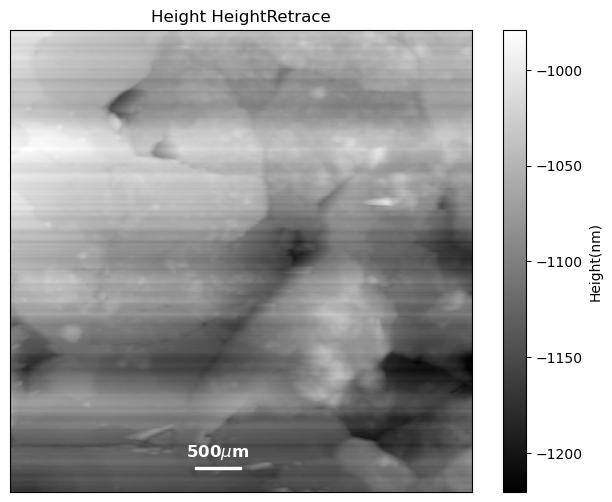

"\nplt.imshow(fully_leveled, cmap='gray', origin='lower')\n# Add a colorbar and labels\nplt.colorbar(label='Height nm')\nplt.title(f'AFM Scan: {channel_name}')\nplt.xlabel('Pixels')\nplt.ylabel('Pixels')"

In [37]:
# 1. Load the height data
# 2. Apply Plane Level to fix overall sample tilt

image_data, scale = load_ibw(file_path=file_path, channel=channel_name)
plane_corrected = plane_level(image_data)

# 3. Apply Line-by-Line Level to fix horizontal scanning artifacts
fully_leveled = line_level_0th_order(plane_corrected)

pixels_x, pixels_y = image_data.shape

x_nm = pixels_x*scale
y_nm = pixels_y *scale


# 4. Save your processed array
#$np.save("leveled_height_data.npy", fully_leveled)

# Plot the 2D image data
# You can change the 'cmap' (colormap) to something like 'magma' or 'gray' if preferred
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(
    image_data, 
    cmap = 'gray', 
    origin = 'lower', 
    extent = [0,x_nm, 0, y_nm]
)
ax.set_xticks ([])
ax.set_yticks([])
plt.colorbar(im, label = "Height(nm)")
scalebar_length = 500
x_pos = x_nm -scalebar_length - (0.5*x_nm)
y_pos = 0.05*y_nm
bar_thickness = y_nm*0.005

scale_bar = patches.Rectangle(
    (x_pos, y_pos), 
    scalebar_length, 
    bar_thickness, 
    color = 'white', 
    zorder = 5
)

ax.add_patch(scale_bar)
units = r"$micron$"
ax.text(
    x_pos + (scalebar_length/2), 
    y_pos + bar_thickness + (0.01*y_nm), 
    fr"{scalebar_length}$\mu$m", 
    color = 'white', 
    ha = 'center', 
    va = 'bottom', 
    fontsize = 12, 
    fontweight = 'bold'
)

plt.title(f"Height {channel_name}")
plt.show()
'''
plt.imshow(fully_leveled, cmap='gray', origin='lower')
# Add a colorbar and labels
plt.colorbar(label='Height nm')
plt.title(f'AFM Scan: {channel_name}')
plt.xlabel('Pixels')
plt.ylabel('Pixels')'''

# Display the plot
#plt.show()

In [ ]:
def readandsave(filepath, savepath): 
    channel_name = "NapPotentialRetrace"

    image_data, pixel_to_nm_scaling = load_ibw(file_path=filepath, channel=channel_name)
    if filepath:  # Check if the user selected a file (didn't click Cancel)
            name = Path(filepath).stem
    
    save_name = f"{savepath}{name}.npy"

    np.save(save_name, image_data)

    print(f"Success! Saved raw array of shape {image_data.shape} as a .npy file.")